In [1]:
import os
import sys
# set gpu to be pci bus id
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional

In [3]:
sys.path.append('/home/jmathew_waller/workspace/e2e-imaging/')
from psf_modules import RMLPSFLayer
from lensless_data_generator import LenslessDataGenerator
from optimizers import E2EOptimizer
from sensor_modules import SensorModule
from reconstruction_modules import WienerDeconv, UNetDeconv

2026-03-09 14:17:21.536789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773091041.554766 3003246 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773091041.560627 3003246 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    sensor_module: eqx.Module
    reconstruction_module: eqx.Module

    def __init__(self, 
                 psf_module,
                 sensor_module,
                 reconstruction_module):
        
        self.psf_module = psf_module
        self.sensor_module = sensor_module
        self.reconstruction_module = reconstruction_module
        

    def __call__(self, x: jnp.ndarray, key: Optional[jax.random.PRNGKey] = None, ensure_positive=True) -> tuple:
        # x: (B, H, W)
        key = jax.random.PRNGKey(0) if key is None else key # TODO: ask claude, is this bad seeding?
        psf, y = self.psf_module(x)  # psf:(K, L), y:(B, H, W)
        noisy_y = self.sensor_module(y, key=key, ensure_positive=ensure_positive)
        x_hat = self.reconstruction_module(noisy_y, psf)     # (B, H, W)
        
        return x_hat, noisy_y, psf

In [ ]:
# general
lr_psf = 1e-3
lr_K = 1e-2
seed_value = 42 #TODO: FIX SEEDING
key = jax.random.PRNGKey(seed_value)

# loading images
tile_rows=3
tile_cols=3
batch_size=32  
dataset_name = 'mnist'
photon_count = 160
subset_fraction = 1

# psf stuff constants
psf_size = (32, 32)
object_size = 32
num_gaussian = 10

# sensor stuff
noise_enabled = True
sensor_array_enabled = True
gaussian_sigma = 0.5

sensor_array_params = { #TODO: figure out if you can save this in wandb?
    "H": 96,
    "W": 96, 
    "rows": 5,
    "cols": 4,
    "sensor_h": 10,
    "sensor_w": 15,
    "spacing_y": 8,
    "spacing_x": 10
}

# recon stuff
recon_name = 'wiener'
log_K = jnp.array(-4.0) #initial starting K value for wiener deconv

# train stuff
num_steps = 500
log_every_print = 20
visualize_every = 50

#wandb logging stuff
use_wandb = False
project_name = 'e2e_imaging_playground'
run_name = f'{dataset_name}_gaussian_sigma_{gaussian_sigma}_photon_count_{photon_count}_num_gaussian_{num_gaussian}'
log_every = 10

In [6]:
# set up wandb config
wandb_config = {
    'general': {
        'seed_value': seed_value,
    },
    
    'dataset': {
        'subset_fraction': subset_fraction,
        'photon_count': photon_count,
        'tile_rows': tile_rows,
        'tile_cols': tile_cols,
        'batch_size': batch_size,
        'dataset_name': dataset_name,
    },
    
    'psf_layer': {
        'object_size': object_size,
        'num_gaussian': num_gaussian,
        'psf_size': psf_size,
        'gaussian_sigma': gaussian_sigma
    },
    
    'optimization': {
        'initial log_K': log_K,
        'learning_rate_psf': lr_psf,
        'learning_rate_K': lr_K
    },
    
    'logging': {
        'use_wandb': use_wandb,
        'project_name': project_name,
        'run_name': run_name,
        'log_every': log_every,
    }
}

In [7]:
# load images!
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)

if dataset_name == 'cifar10':
    x_train, x_test = data_generator.load_cifar10_data()
elif dataset_name == 'mnist':
    x_train, x_test = data_generator.load_mnist_data()

train_dataset = data_generator.create_dataset(x_train, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)
x_train[0].shape[0] * tile_rows

2026-03-09 14:17:25.933021: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1773091045.933225 3003246 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22165 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:5e:00.0, compute capability: 8.6


96

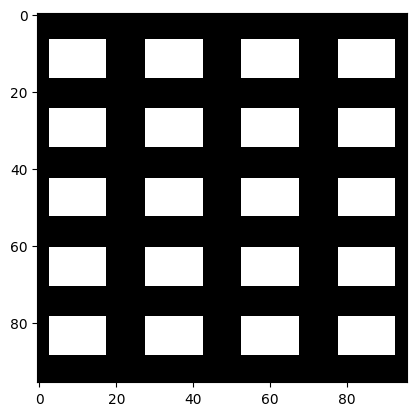

In [8]:
# the model
key_1, subkey_1 = jax.random.split(key)
key_2, subkey_2 = jax.random.split(key_1)
key_3, subkey_3 = jax.random.split(key_2)

psf_module = RMLPSFLayer(object_size=32, num_gaussians=10, psf_size=psf_size, key=subkey_1)
sensor_module = SensorModule(photon_count=photon_count, 
                             noise_enabled=noise_enabled,
                             sensor_array_enabled=sensor_array_enabled, 
                             gaussian_sigma=gaussian_sigma, 
                             sensor_array_params= sensor_array_params)

if recon_name == 'wiener':
    reconstruction_module = WienerDeconv(log_K)
if recon_name == 'unet':
    reconstruction_module = UNetDeconv(2, x_train[0].shape[0] * tile_rows, key = subkey_2) # TODO: fix the size dimension (second entry)

model = E2E(psf_module=psf_module, sensor_module=sensor_module, reconstruction_module=reconstruction_module)
plt.imshow(model.sensor_module.create_sensor_array(), cmap='gray')
plt.show()

In [9]:
e2e_optimizer = E2EOptimizer(
    model=model,
    lr_psf=lr_psf,
    lr_recon=lr_K,
    use_wandb=use_wandb, 
    project_name='e2e_imaging',
    run_name=run_name,
    wandb_config=wandb_config
)

  0%|          | 0/100 [00:00<?, ?it/s]E0309 14:17:32.732112 3003246 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


step 0/100  loss=0.085368


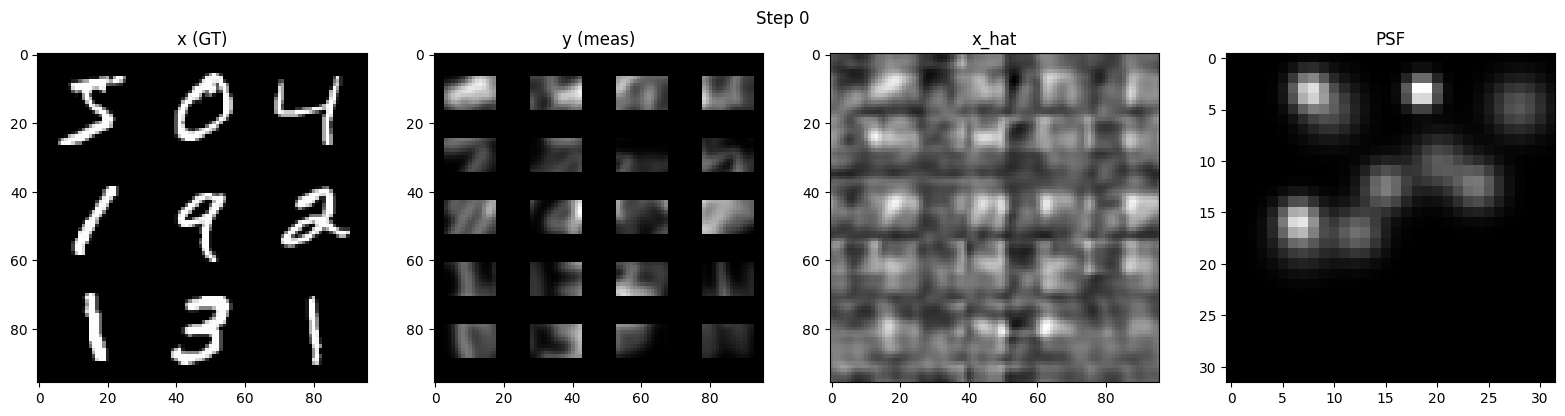

  4%|▍         | 4/100 [00:14<03:43,  2.33s/it]

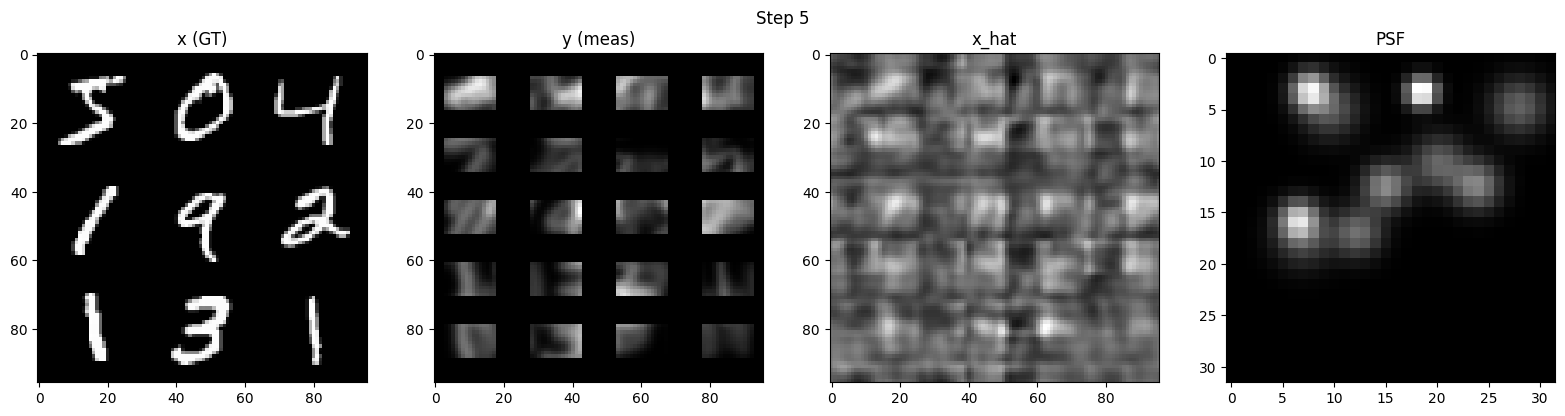

  9%|▉         | 9/100 [00:15<01:01,  1.48it/s]

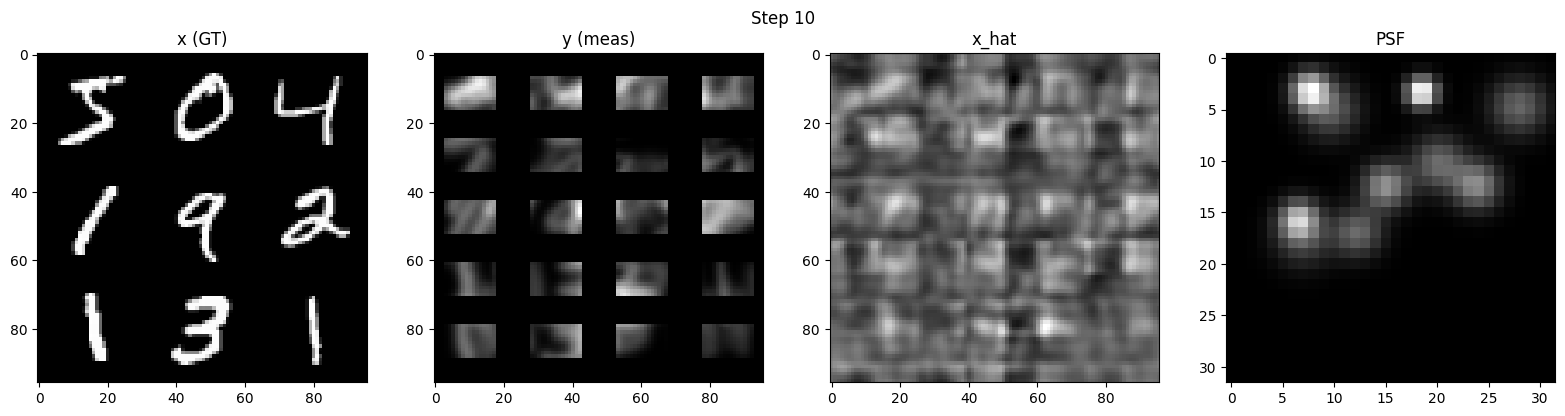

 15%|█▌        | 15/100 [00:16<00:22,  3.70it/s]

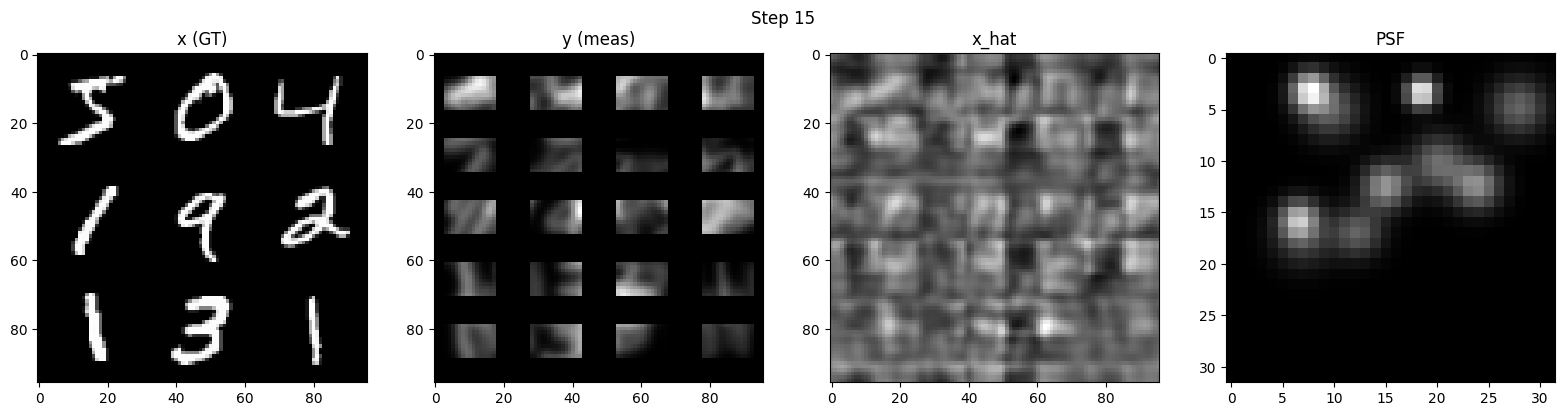

 20%|██        | 20/100 [00:17<00:14,  5.71it/s]

step 20/100  loss=0.087315


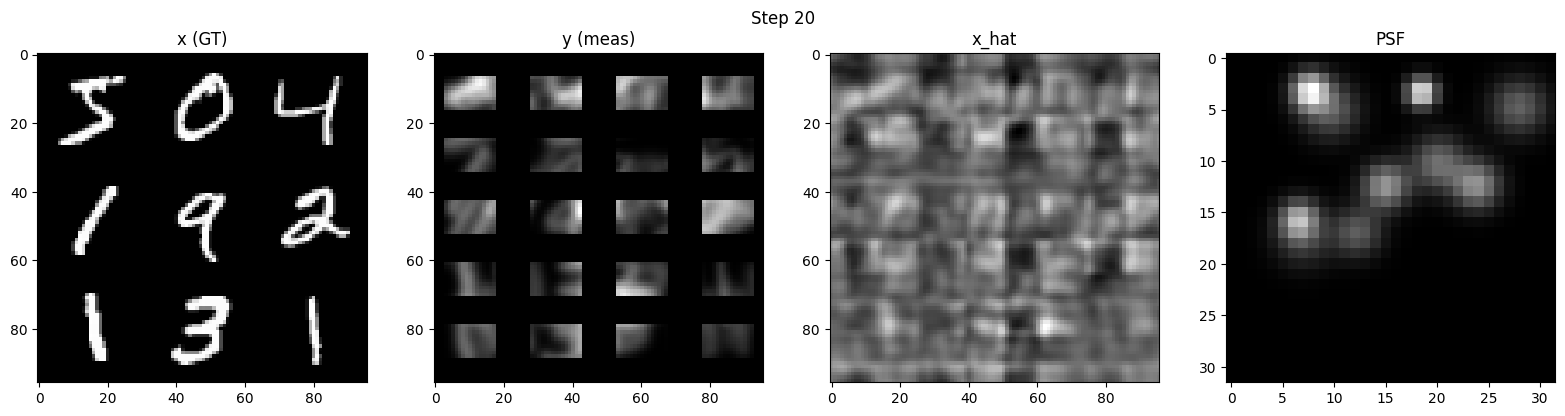

 24%|██▍       | 24/100 [00:18<00:12,  6.18it/s]

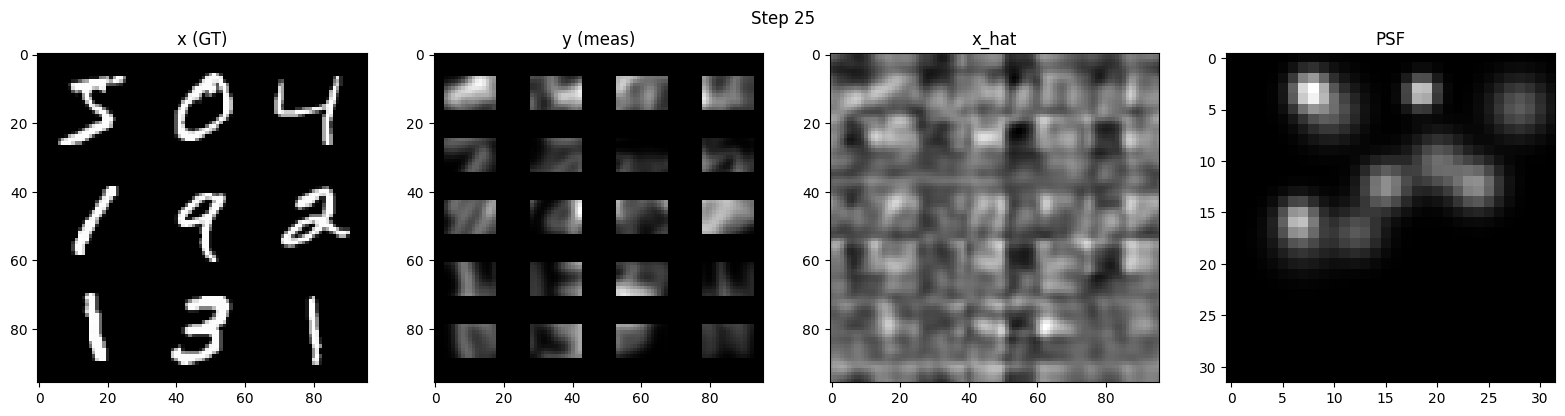

 30%|███       | 30/100 [00:19<00:11,  6.19it/s]

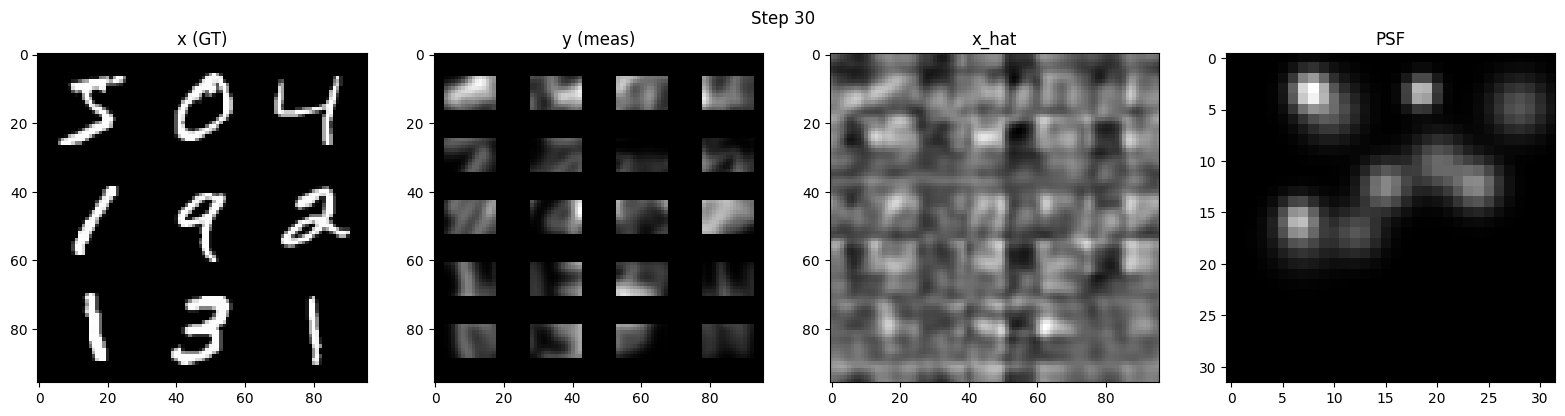

 35%|███▌      | 35/100 [00:20<00:09,  7.03it/s]

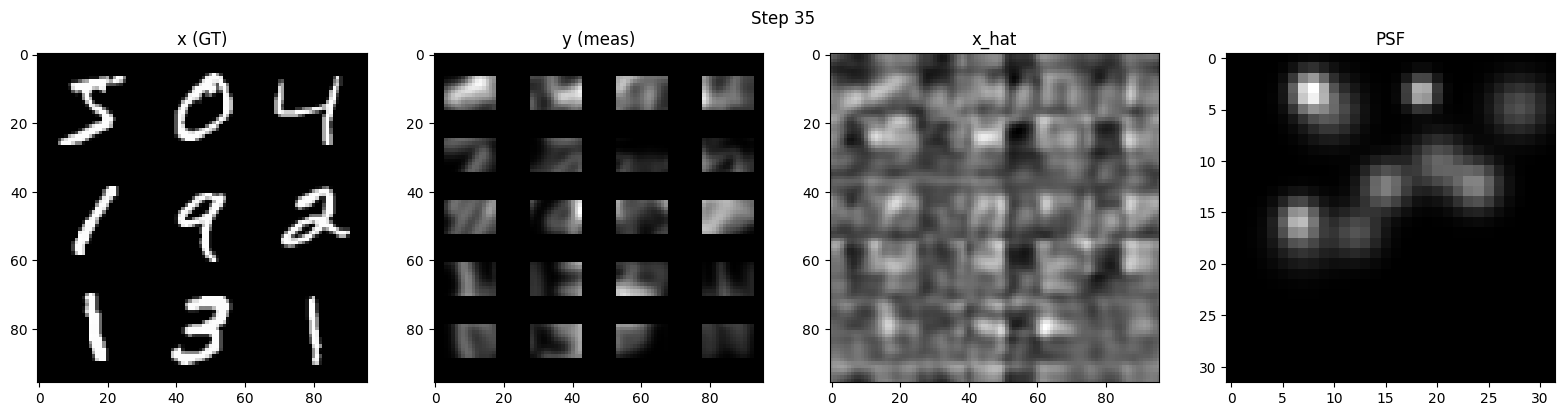

 40%|████      | 40/100 [00:20<00:08,  7.36it/s]

step 40/100  loss=0.078181


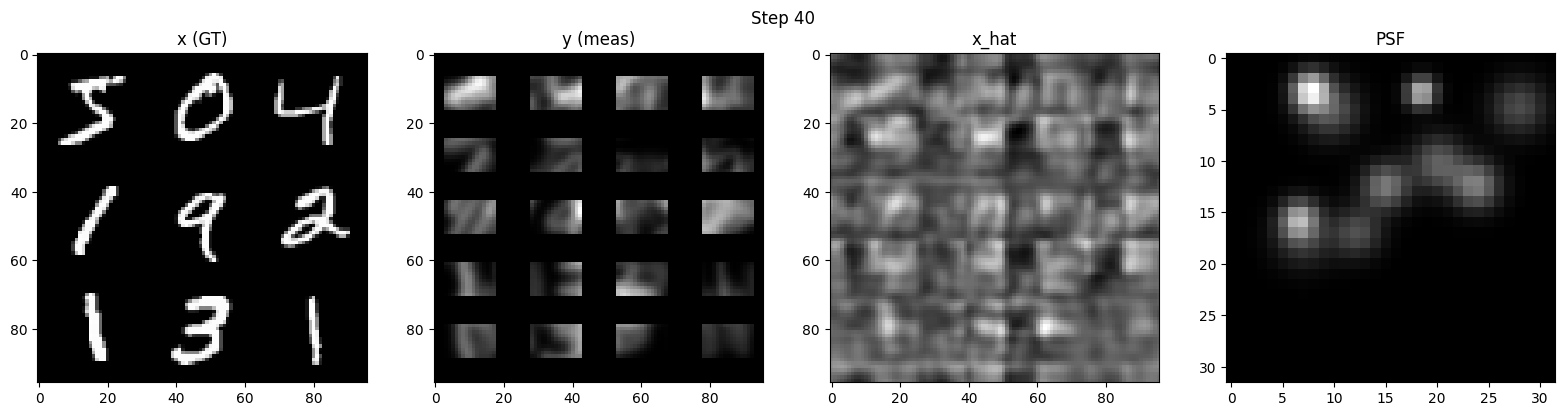

 45%|████▌     | 45/100 [00:21<00:07,  7.74it/s]

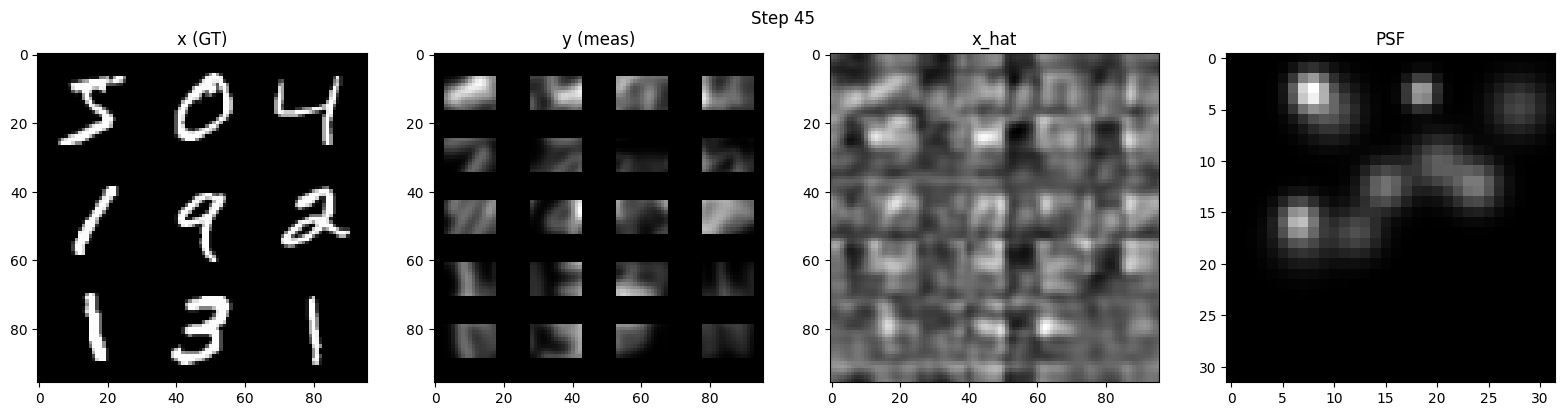

 50%|█████     | 50/100 [00:22<00:06,  8.07it/s]

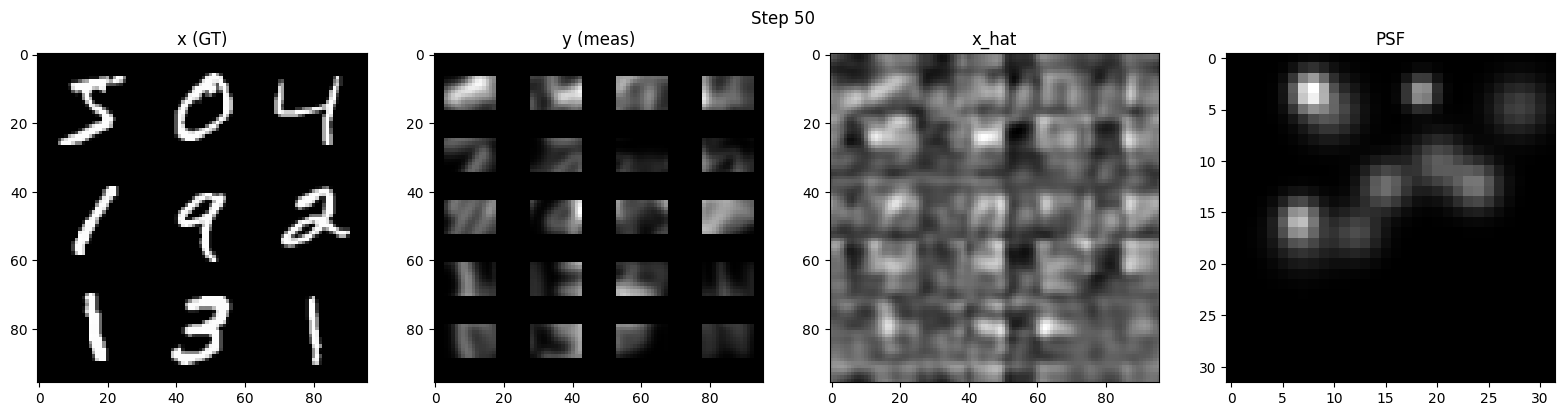

 54%|█████▍    | 54/100 [00:22<00:06,  7.06it/s]

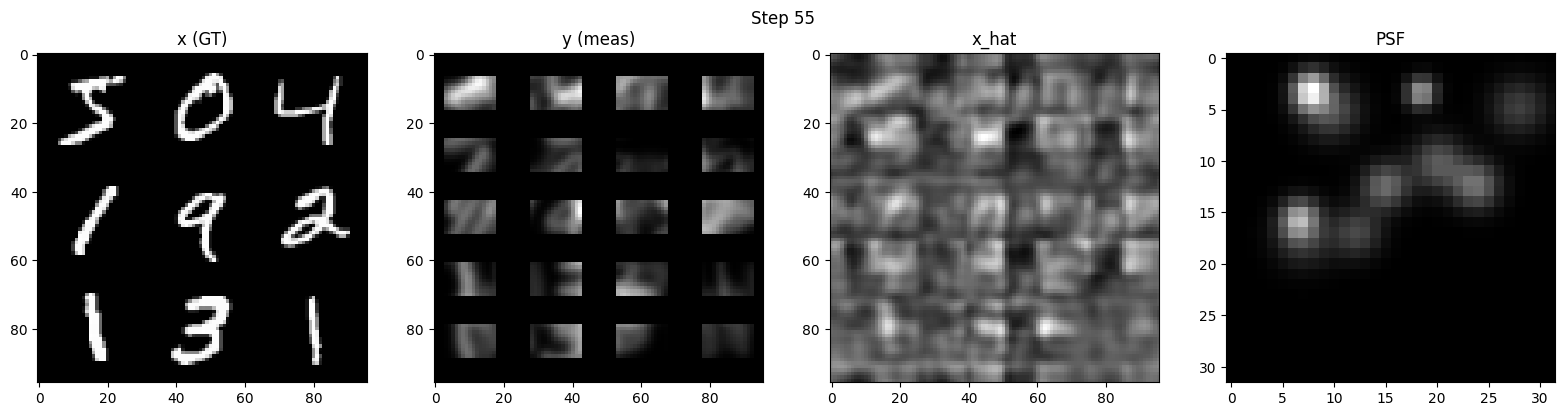

 60%|██████    | 60/100 [00:23<00:05,  7.84it/s]

step 60/100  loss=0.074659


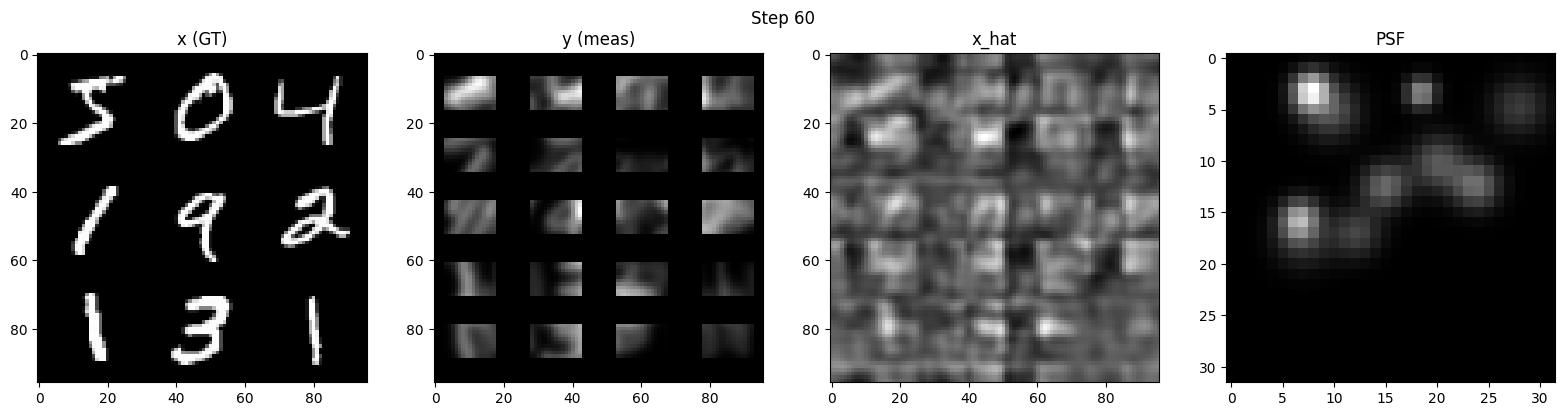

 64%|██████▍   | 64/100 [00:24<00:05,  6.99it/s]

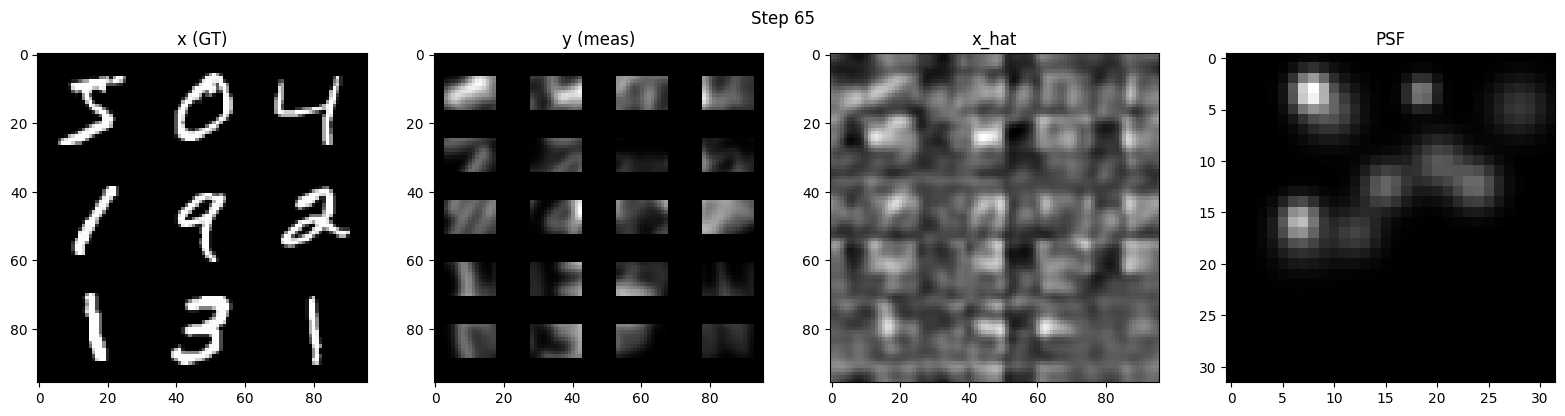

 70%|███████   | 70/100 [00:25<00:04,  7.41it/s]

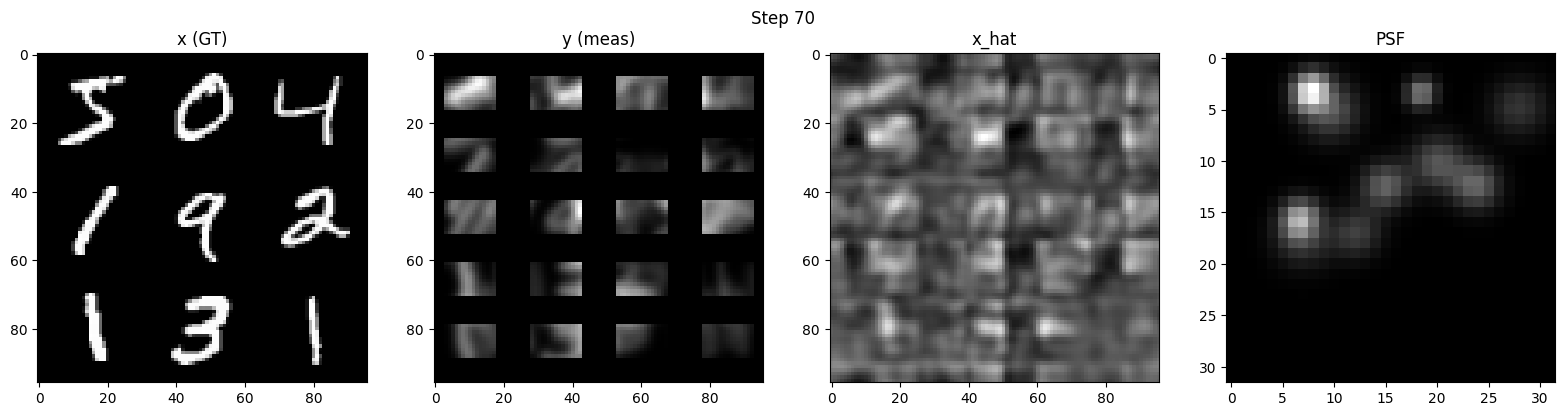

 75%|███████▌  | 75/100 [00:26<00:03,  7.36it/s]

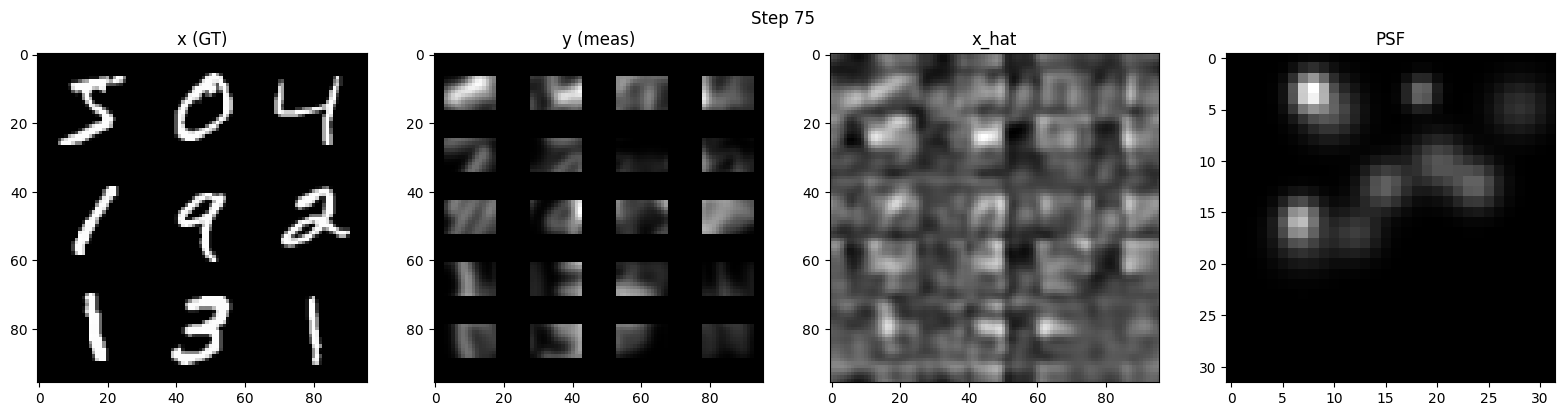

 80%|████████  | 80/100 [00:27<00:02,  7.71it/s]

step 80/100  loss=0.083557


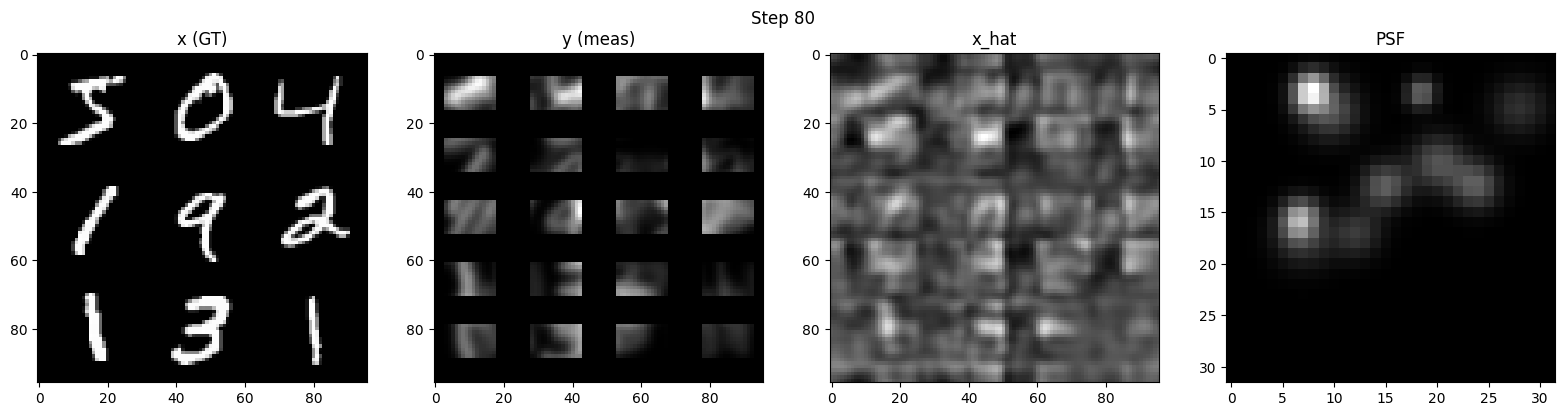

 85%|████████▌ | 85/100 [00:27<00:01,  7.67it/s]

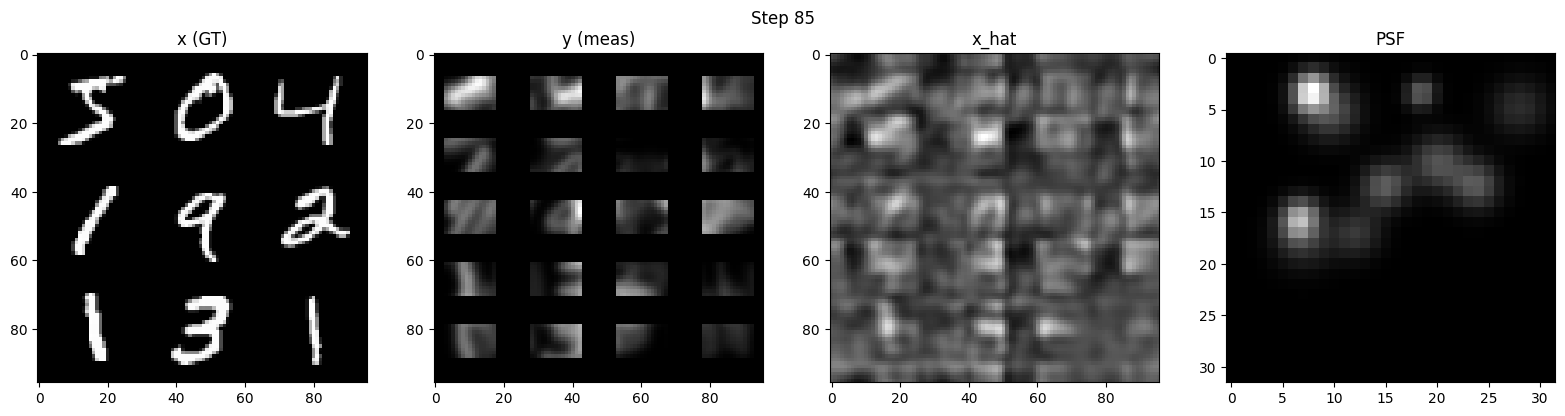

 90%|█████████ | 90/100 [00:29<00:01,  5.88it/s]

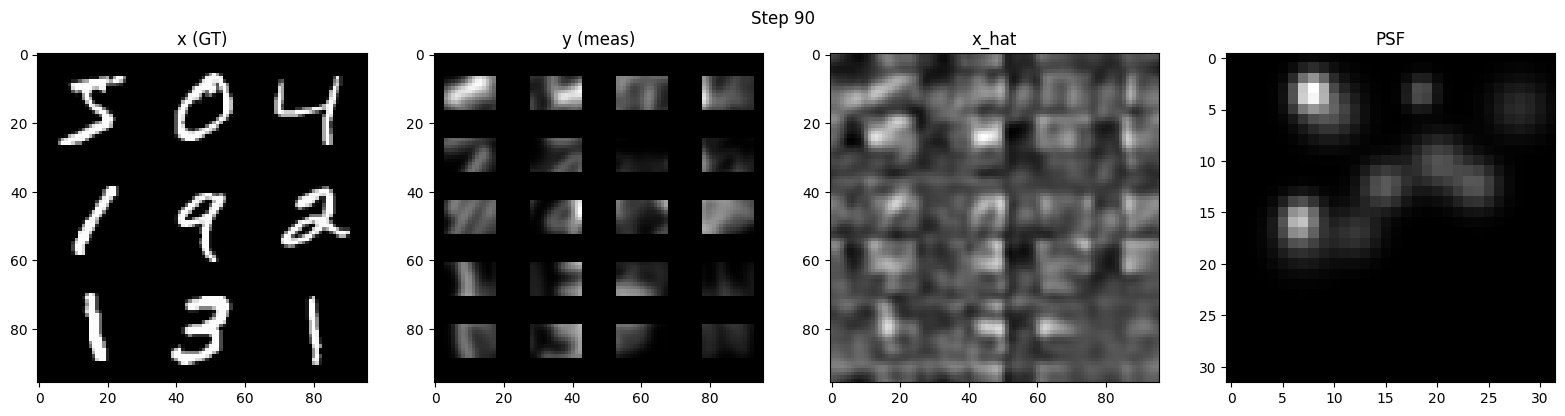

 95%|█████████▌| 95/100 [00:29<00:00,  6.75it/s]

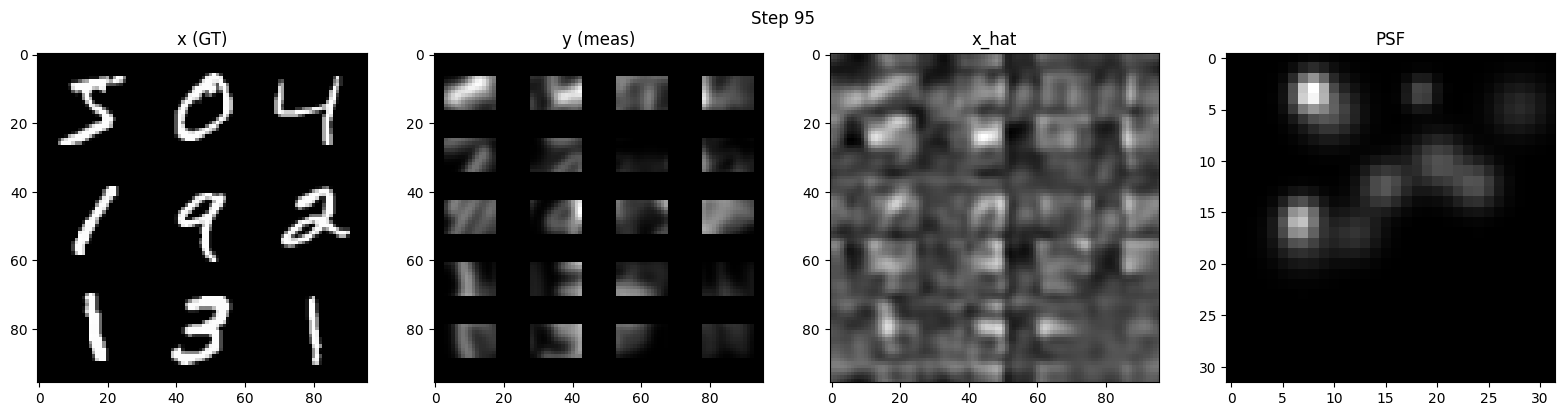

 98%|█████████▊| 98/100 [00:30<00:00,  6.15it/s]

step 99/100  loss=0.077394


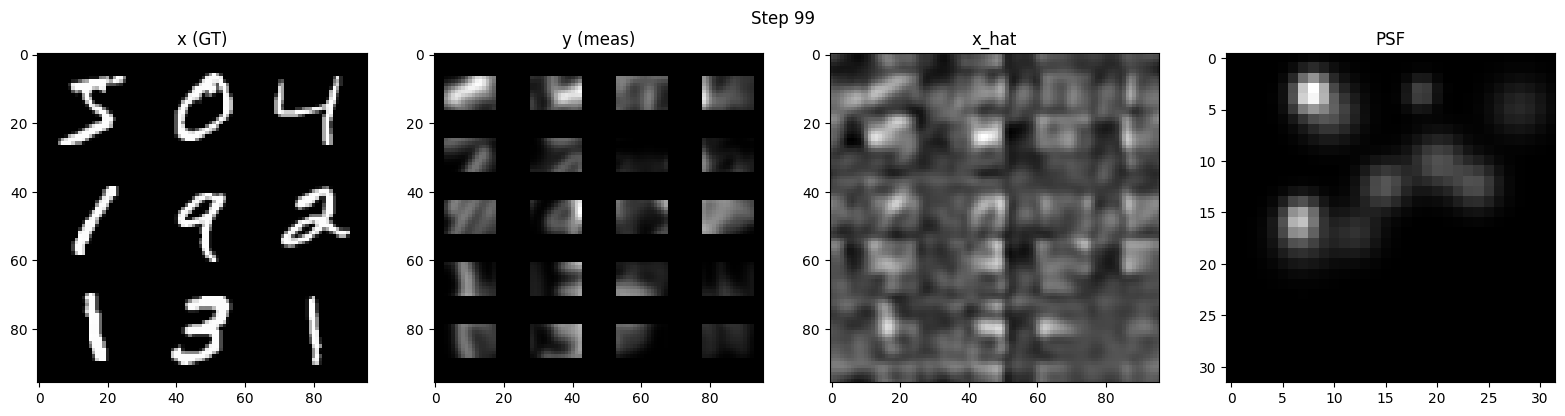

100%|██████████| 100/100 [00:31<00:00,  3.22it/s]


In [10]:
optimized_imaging_system = e2e_optimizer.optimize(
    train_dataset,
    num_steps=num_steps,
    log_every=log_every_print,
    visualize_every=visualize_every,
    key=subkey_3
)

In [11]:
model.reconstruction_module.log_K

Array(-4., dtype=float32, weak_type=True)

In [12]:
params = eqx.filter(model, eqx.is_array)
leaves, treedef = jax.tree_util.tree_flatten_with_path(params)
for path, leaf in leaves:
    has_log_K = any(
        isinstance(k, jax.tree_util.GetAttrKey) and k.name == 'log_K'
        for k in path
    )
    label = 'K' if has_log_K else 'psf'
    print(f"{label:4s}  {str(path):60s}  {leaf.shape}")

psf   (GetAttrKey(name='psf_module'), GetAttrKey(name='means'))     (10, 2)
psf   (GetAttrKey(name='psf_module'), GetAttrKey(name='covs'))      (10, 2, 2)
psf   (GetAttrKey(name='psf_module'), GetAttrKey(name='weights'))   (10,)
psf   (GetAttrKey(name='psf_module'), GetAttrKey(name='grid'))      (1024, 2)
K     (GetAttrKey(name='reconstruction_module'), GetAttrKey(name='log_K'))  ()
